### A notebook to analyze trackarrays

In [1]:
import croparray as ca
from pathlib import Path

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/12xSunTAg-KDM5B-XBP1SA-MS2/CombinedStacks/CropArrays")
nc_files = sorted(DATA_DIR.glob("*.nc"))

# Measurement parameters
REF_CH = 0  # Optional reference channel for best_z_proj (if use_zc=False, i.e. when Z not tracked)
DISK_R = 5  # Radius of disk in pixels to measure signal
DISK_BG = 7 # Radius of single pixel ring around disk to measure background 
ROLL_N = 3  # Rolling z-average for signal measurement.

In [3]:
# Open directly as trackarrays and make measurement; 
# Note dropping memory-intensive "int" variable after measurement (which creates best_z layer)
my_ta = ca.tools.open_as_trackarray(nc_files[0], drop_vars=None, as_object=True).measure_signal(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N, drop_int=True) 

In [4]:
my_ta.ops.apply(ca.tools.binarize_crop_manual, channels=[0], source="best_z", out_name="ch{ch}_mask", func_kwargs=dict(q=0.45, q_range=(0.02,0.999), q_positive_only=True, close_px=1, smooth_px=0, fill_holes=False, return_uint8=True), compute_sum_xy=True, sum_name="{out}_area_px");

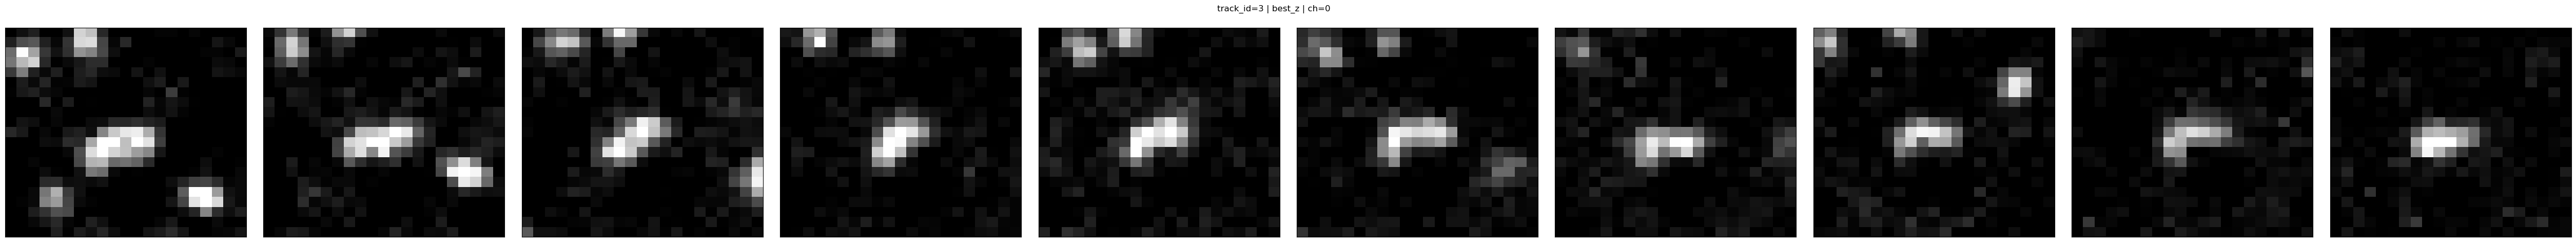

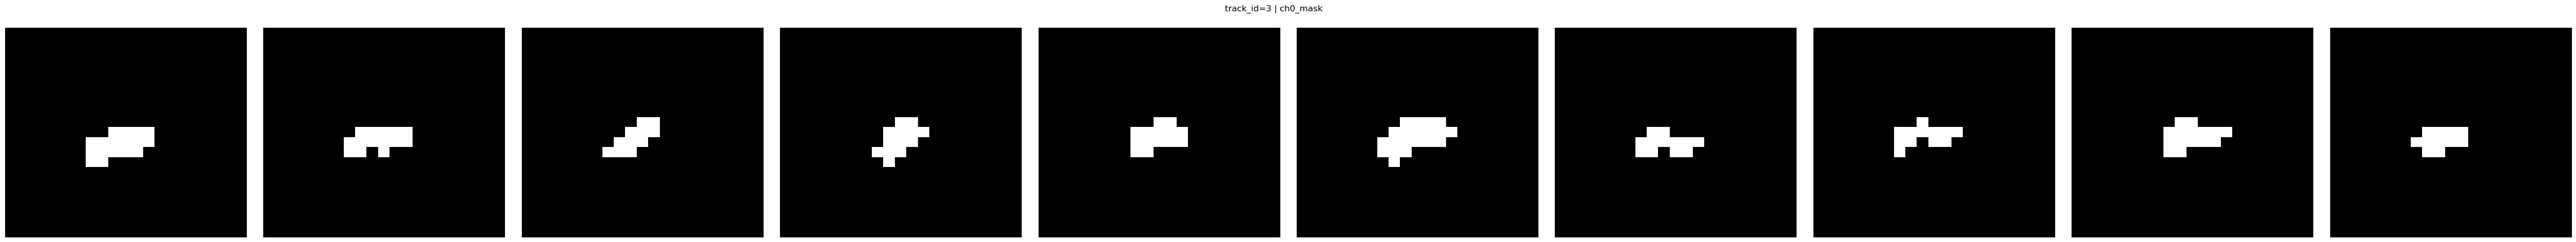

In [5]:
my_ta.tplot.plot_trackarray_crops(fov=0,track_ids=[3],t=(0,10,1),suppress_labels=True);
my_ta.tplot.plot_trackarray_crops(fov=0,track_ids=[3],t=(0,10,1),suppress_labels=True,layer="ch0_mask");

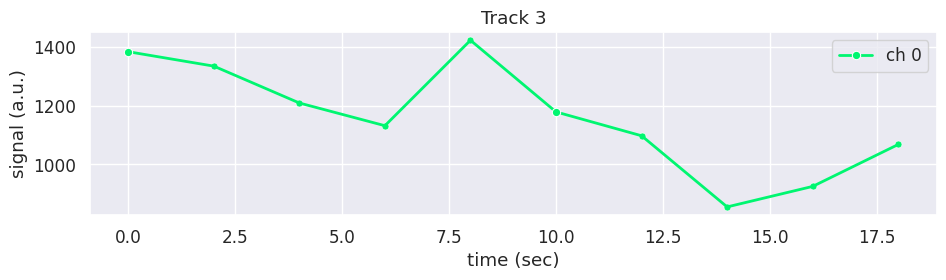

In [6]:
my_ta.tplot.plot_track_signal_traces(track_ids=[3],figsize=(9,3))

In [ ]:
import napari

viewer, layers = my_ta.napari.montage_viewer(
    row="track_id",
    col="track_id",
    show=("best_z", "ch0_mask"),
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch0_mask": "magenta","best_z": "green"},
    image_contrast=(0,100)
)
